Dataset Loaded Successfully

Top Correlated Features:
Is_Fraudulent                         1.000000
Provider_Patient_Distance_Miles       0.831591
Number_of_Previous_Claims_Provider    0.798729
Number_of_Procedures                  0.796273
Number_of_Previous_Claims_Patient     0.762867
Length_of_Stay_Days                   0.726717
Patient_Age                           0.509265
Claim_Submitted_Late                  0.351456
Claim_Amount                          0.345006
Admission_Type                        0.314556
Name: Is_Fraudulent, dtype: float64


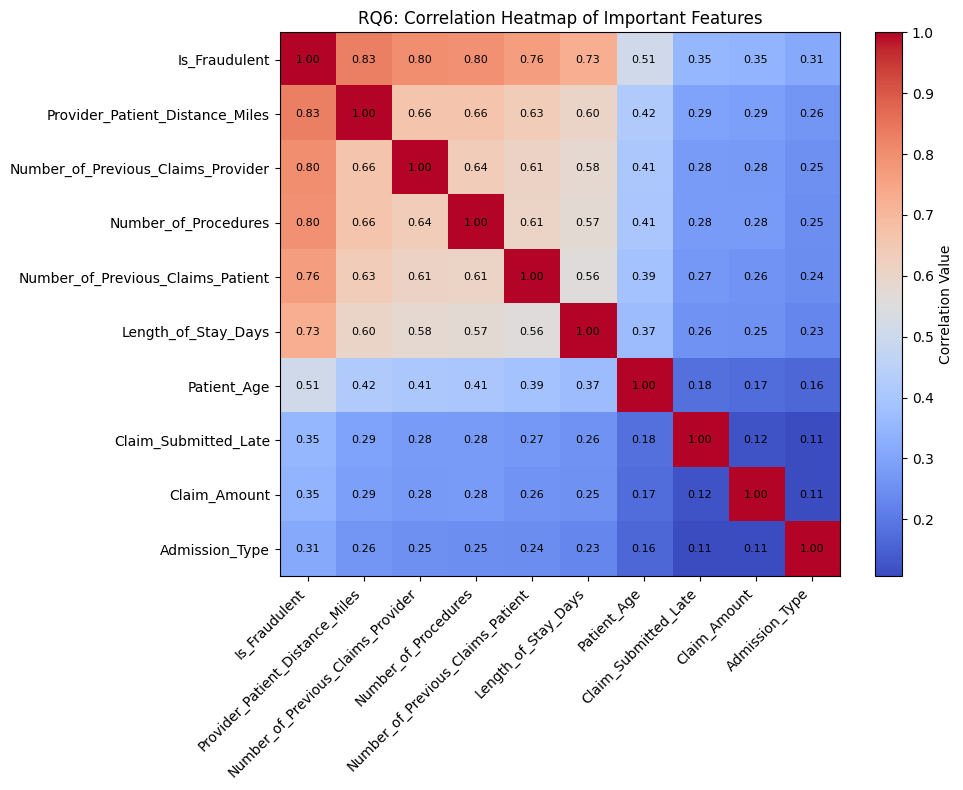


Process Completed Successfully


In [1]:
# ============================================
# RQ6: Correlation Heatmap Analysis
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------
# Step 1: Load Dataset
# --------------------------------------------

df = pd.read_csv(
    r"C:\Users\dheer\Desktop\ML\cleaned_dataset.csv"
)

df = df.drop_duplicates()

print("Dataset Loaded Successfully")

# --------------------------------------------
# Step 2: Remove Identifier Columns
# --------------------------------------------

ids_to_drop = [
    'Patient_ID',
    'Policy_Number',
    'Claim_ID',
    'Hospital_ID',
    'Unnamed: 0'
]

df = df.drop(
    columns=[c for c in ids_to_drop if c in df.columns]
)

# --------------------------------------------
# Step 3: Convert Categorical Variables
# --------------------------------------------

df = pd.get_dummies(df, drop_first=True)

# --------------------------------------------
# Step 4: Correlation Matrix
# --------------------------------------------

correlation_matrix = df.corr(numeric_only=True)

# Select top correlated features with fraud
target_col = 'Is_Fraudulent'

top_corr = (
    correlation_matrix[target_col]
    .abs()
    .sort_values(ascending=False)
    .head(10)
)

selected_features = top_corr.index

heatmap_data = correlation_matrix.loc[
    selected_features,
    selected_features
]

print("\nTop Correlated Features:")
print(top_corr)

# --------------------------------------------
# Step 5: Create Heatmap
# --------------------------------------------

plt.figure(figsize=(10, 8))

plt.imshow(
    heatmap_data,
    cmap='coolwarm',
    aspect='auto'
)

# Axis labels
plt.xticks(
    range(len(selected_features)),
    selected_features,
    rotation=45,
    ha='right'
)

plt.yticks(
    range(len(selected_features)),
    selected_features
)

# Add color bar
plt.colorbar(label='Correlation Value')

plt.title('RQ6: Correlation Heatmap of Important Features')

# Add correlation values inside cells
for i in range(len(selected_features)):
    for j in range(len(selected_features)):
        plt.text(
            j,
            i,
            f"{heatmap_data.iloc[i, j]:.2f}",
            ha='center',
            va='center',
            fontsize=8
        )

plt.tight_layout()

# --------------------------------------------
# Step 6: Save Results
# --------------------------------------------

plt.savefig(
    r"C:\Users\dheer\Desktop\ML\RQ6_heatmap.png",
    bbox_inches='tight'
)

heatmap_data.to_csv(
    r"C:\Users\dheer\Desktop\ML\RQ6_heatmap_table.csv"
)

plt.show()

print("\nProcess Completed Successfully")